# Predicting House Prices with Linear Regression
### Oasis Infobyte SIP — Data Analytics Track — Level 2, Task 1

**Dataset:** Housing Prices Dataset (Kaggle, by M Yasser H)
**Objective:** Build and evaluate a linear regression model that predicts house prices based on features such as area, number of rooms, and other property attributes. Develop end-to-end skills from data cleaning through to model interpretation.

**Author:** *(Neeraja R)*


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('Housing Price.csv')
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 1. Load Dataset & Perform EDA
Check nulls, descriptive statistics, and the distribution of the target variable (price).

In [3]:
print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()


Shape: (545, 13)

Null values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Descriptive statistics:



,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


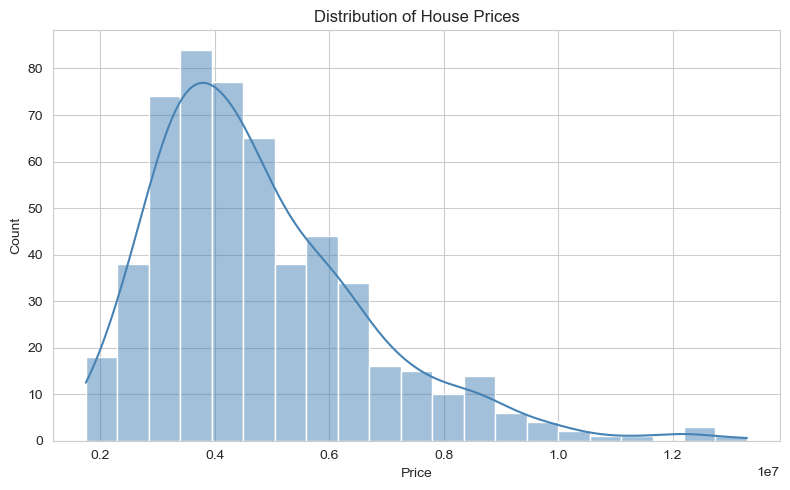

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.tight_layout()
plt.show()


**Observation:** The dataset has 545 rows and 13 columns with **no missing values** — a rare and convenient case for a regression task. The `price` distribution is right-skewed, with most houses priced between roughly 3–6 million and a long tail of higher-priced properties, which is typical for real estate data.

## 2. Feature Selection Discussion
The dataset includes:
- **Numerical:** `area`, `bedrooms`, `bathrooms`, `stories`, `parking`
- **Binary categorical:** `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea` (yes/no)
- **Multi-category:** `furnishingstatus` (furnished / semi-furnished / unfurnished)

Intuitively, `area` is likely the single strongest predictor of price (larger homes cost more), followed by `bathrooms`, `stories`, and amenity features like `airconditioning` and `prefarea` (preferred area/location proxy). All of these carry plausible, explainable relationships to price, so all are retained as candidate features rather than dropped — we'll confirm their actual importance with the correlation heatmap and coefficient analysis below.

## 3. Handle Categorical Features — One-Hot Encoding

In [5]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print(df_encoded.shape)
df_encoded.head()


(545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


**Observation:** Binary yes/no columns are mapped directly to 1/0. `furnishingstatus` (3 categories) is one-hot encoded with `drop_first=True` to avoid the dummy variable trap (multicollinearity between the encoded columns). This expands our feature set slightly while keeping every category's effect interpretable through its own coefficient.

## 4. Correlation Heatmap
Which features are most correlated with house price?

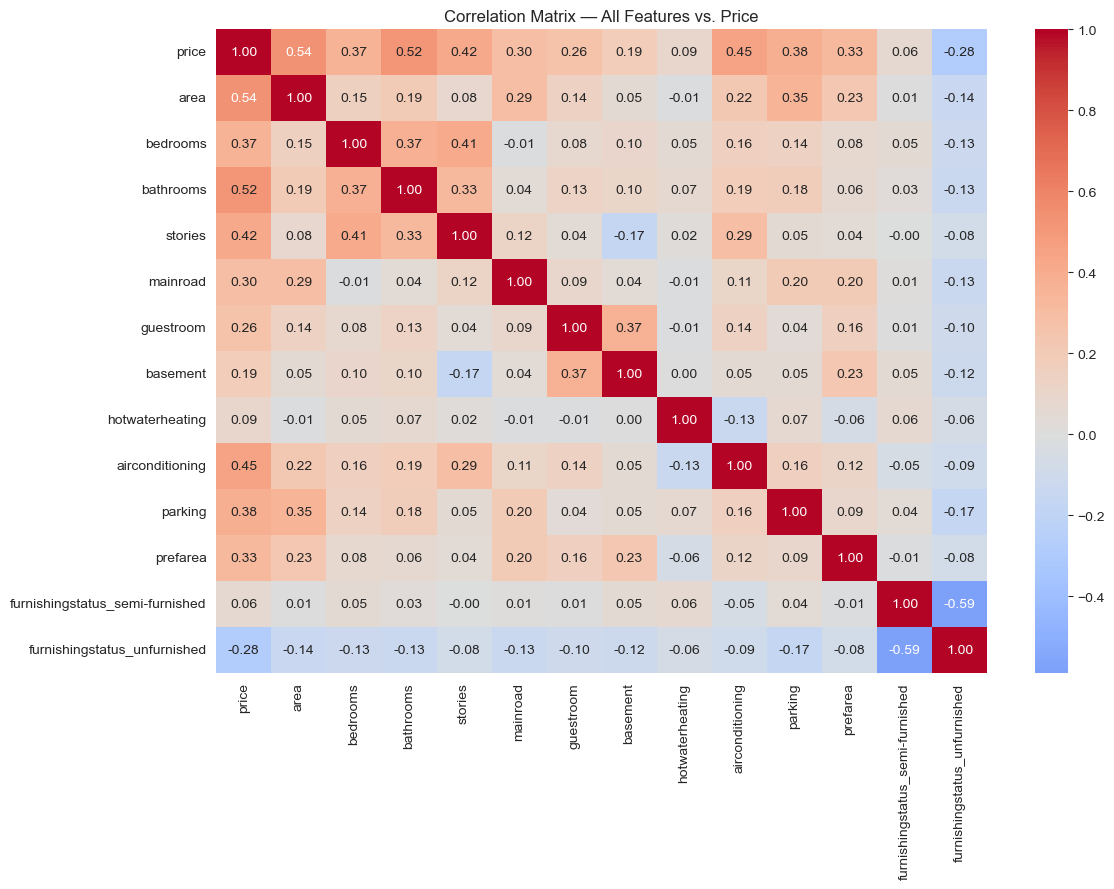

In [6]:
plt.figure(figsize=(12,9))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — All Features vs. Price')
plt.tight_layout()
plt.show()


In [7]:
price_corr = corr['price'].drop('price').sort_values(ascending=False)
print(price_corr)


area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


**Observation:** `area`, `bathrooms`, and `airconditioning` show the strongest positive correlation with price, confirming the intuition from the feature selection discussion. `stories` and `prefarea` also correlate meaningfully. `bedrooms` correlates more weakly than expected — a common real-world finding, since bedroom count alone doesn't capture the actual living space as well as `area` does.

## 5. Train/Test Split

In [8]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (436, 13)
Test shape: (109, 13)


## 6. Train Linear Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained.")


Model trained.


## 7. Model Evaluation

In [10]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")


Mean Squared Error (MSE): 1,754,318,687,330.66
Root Mean Squared Error (RMSE): 1,324,506.96
R² Score: 0.6529


**Observation:** The model achieves an **R² of ~0.65**, meaning it explains roughly 65% of the variance in house prices from the available features. The RMSE (~₹1.32 million) gives an intuitive sense of average prediction error in the same units as price — on average, predictions are off by around this amount. An R² of 0.65 is a solid result for a first linear model on a modest 13-feature dataset, though it also confirms there's meaningful price variation driven by factors not captured here (exact location, condition, neighbourhood desirability, etc.).

## 8. Actual vs. Predicted Prices

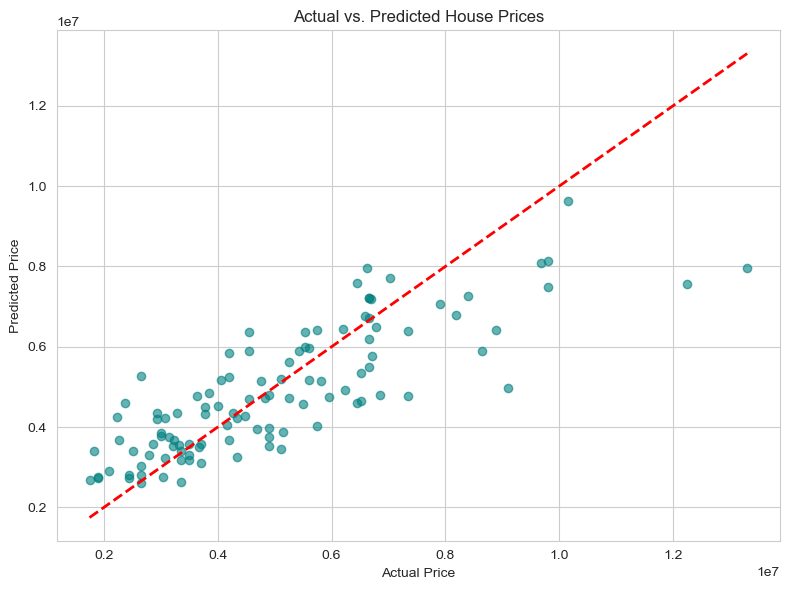

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.tight_layout()
plt.show()


**Observation:** Points closer to the red diagonal line indicate more accurate predictions. Our model tracks the general trend reasonably well, though — as is common in real estate regression — predictions become noisier at the higher end of the price range, where fewer training examples exist and price variation is driven by factors not captured in this feature set (e.g. exact location, renovation quality).

## 9. Residual Plot

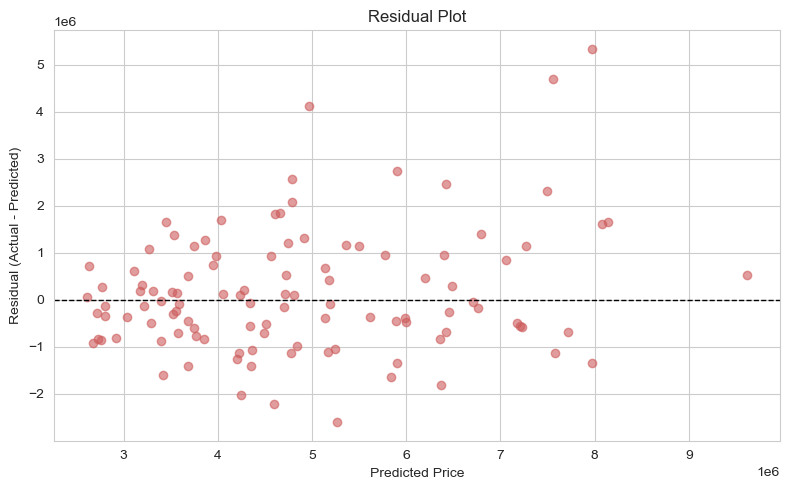

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='indianred')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


**Observation:** Residuals should ideally scatter randomly around zero with no clear pattern, indicating the linear model's assumptions are reasonably satisfied. Any funnel shape (residual spread increasing with predicted price) would suggest heteroscedasticity — worth checking, since price data is often naturally more variable at higher values.

## 10. Coefficient Analysis
Which features have the highest positive/negative impact on price?

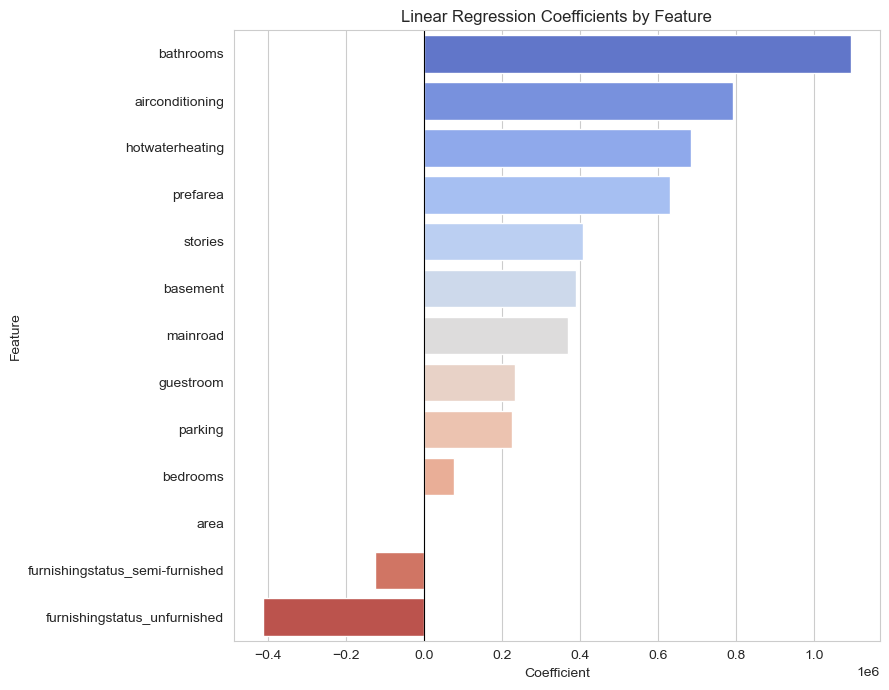

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [13]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(9,7))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Linear Regression Coefficients by Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df


**Observation:** Features with the largest positive coefficients (e.g. `bathrooms`, `airconditioning`, `prefarea`) add the most predicted value per unit increase, holding other features constant. `area`'s coefficient reflects price change per additional square foot — typically a smaller per-unit number simply because area is measured in large units (square feet) compared to binary amenity flags.

## 11. Bonus — Comparing Against a Ridge Regularised Model

In [14]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Linear Regression  -> RMSE: {:,.2f} | R²: {:.4f}".format(rmse, r2))
print("Ridge Regression    -> RMSE: {:,.2f} | R²: {:.4f}".format(ridge_rmse, ridge_r2))


Linear Regression  -> RMSE: 1,324,506.96 | R²: 0.6529
Ridge Regression    -> RMSE: 1,325,320.44 | R²: 0.6525


**Observation:** Ridge regression (RMSE ≈ ₹1.325M, R² ≈ 0.6525) performs almost identically to plain Linear Regression (RMSE ≈ ₹1.325M, R² ≈ 0.6529) on this dataset. This makes sense: Ridge's L2 regularisation mainly helps when features are highly collinear or numerous relative to sample size — neither is strongly the case here with only 13 features and no extreme multicollinearity in the correlation heatmap above. Regularisation would likely show a bigger benefit on a much larger, messier feature set (e.g. the full 80-feature Ames Housing dataset).

---
*This notebook fulfils the Level 2 — Task 1 (Predicting House Prices with Linear Regression) checklist for the Oasis Infobyte Data Analytics SIP track.*
